In [1]:
# last class recap 
# -> CNN - convoltional nueral network -i mage data 
# code - leopard omage - flip 

Image Classification using CNN
Train a CNN model with image dataset :
* Import libraries and dataset - flowers dataset - flower images - CNN with flower images
* Provide some flower image and predict which flower it is
* Retreieve images
* Create some training set, validation set
* Preprocess and normalize
* Create a CNN - data augumentation 
* Compile mode, train mode, visualzie the result 
* Predicition 



In [32]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib


In [33]:
data_dir.resolve()

PosixPath('/Users/angelajohnson/.keras/datasets/flower_photos_extracted/flower_photos')

In [34]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"  # compressed dataset
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)  # extract the .tgz file
data_dir = pathlib.Path('/Users/angelajohnson/.keras/datasets/flower_photos_extracted/flower_photos')


import urllib.request
import tarfile

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
urllib.request.urlretrieve(url, "flower_photos.tgz")

tar = tarfile.open("flower_photos.tgz")
tar.extractall()
tar.close()

data_dir = pathlib.Path("flower_photos")


In [35]:
# Count and Retreive the images
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


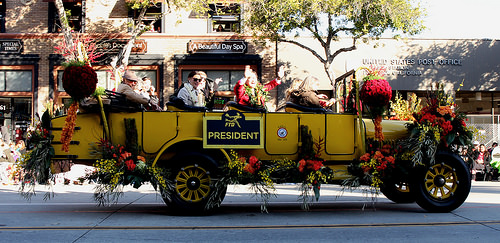

In [46]:
roses = list(data_dir.glob('roses/*')) # fetching data_dir/roses
PIL.Image.open(str(roses[0]))

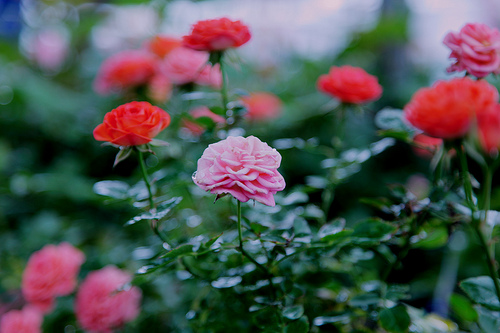

In [37]:
PIL.Image.open(str(roses[1]))

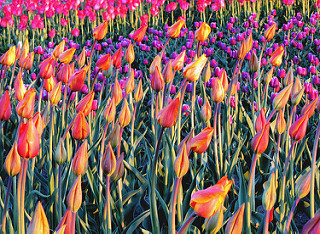

In [38]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [43]:
# creating a training dataset
batch_size = 32
img_height = 180 
img_width = 180 

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = 'training', 
    seed = 123, 
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


2025-12-20 06:57:05.670960: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-12-20 06:57:05.671343: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-12-20 06:57:05.672196: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-12-20 06:57:05.672243: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-20 06:57:05.672579: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [44]:
# create a vlaidation dataset 
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = 'validation', 
    seed = 123, 
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [47]:
# fetch class name 
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [49]:
# preprocess and normalize the dataset 

# autotune setting up -> its a tensorflow constant that decideds how many paralled threads should run 
AUTOTUNE = tf.data.AUTOTUNE 

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# buffer size = 32?

In [50]:
# normalization 
normalization_layer = layers.Rescaling(1./255) # pixels range from 0-255 
normalized_ds = train_ds.map(lambda x, y : (normalization_layer(x), y))
images_batch, labels_batch = next(iter(normalized_ds))
first_image = images_batch[0]
print(np.min(first_image), np.max(first_image))

0.0 1.0


* wherever the pixel is 0 it its converted to 0.0
* where pixel is 255 its is converted to 1.0

------
* makes your CNN train faster, smoother, and with better accuracy by preparing your images properly

In [52]:
# create a CNN with data augmentation 

# create pipeline 
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal', input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


/Users/angelajohnson/miniforge3/envs/tfarm/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
# Number of classes in the dataset (flowers)
num_classes = len(class_names)

model = Sequential([

    # ---------------------------------------------
    # Data Augmentation Layer
    # Randomly flips/rotates/zooms images to help the
    # model generalize better and avoid overfitting.
    # ---------------------------------------------
    data_augmentation,

    # ---------------------------------------------
    # Normalize pixel values from [0,255] → [0,1]
    # Helps training stability and improves convergence.
    # ---------------------------------------------
    layers.Rescaling(1./255),

    # ---------------------------------------------
    # First Convolutional Block
    # Conv2D extracts low-level features (edges, textures)
    # padding='same' keeps spatial dimensions unchanged
    # activation='relu' introduces non-linearity
    # ---------------------------------------------
    layers.Conv2D(16, 3, padding='same', activation='relu'),

    # Downsampling — reduces image size and computation,
    # keeps only the most important features
    layers.MaxPooling2D(),

    # ---------------------------------------------
    # Second Convolutional Block
    # Learns deeper/more complex features
    # 32 filters → more feature maps
    # ---------------------------------------------
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # ---------------------------------------------
    # Third Convolutional Block
    # Even deeper features (shapes, patterns)
    # ---------------------------------------------
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # ---------------------------------------------
    # Dropout Layer
    # Randomly drops neurons during training
    # Helps prevent overfitting to training images
    # ---------------------------------------------
    layers.Dropout(0.2),

    # ---------------------------------------------
    # Flatten converts the 3D feature maps → 1D vector
    # Needed before feeding into Dense layers
    # ---------------------------------------------
    layers.Flatten(),

    # ---------------------------------------------
    # Fully-connected dense layer
    # Learns combinations of extracted features
    # 128 units → higher capacity
    # ---------------------------------------------
    layers.Dense(128, activation='relu'),

    # ---------------------------------------------
    # Output Layer
    # One output node per flower class
    # No activation because we'll use
    # SparseCategoricalCrossentropy(from_logits=True)
    # ---------------------------------------------
    layers.Dense(num_classes)
])


In [56]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.compile(optimizer = 'adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
              metrics= ['accuracy'])


---

# ✅ **📌 Explanation of the `model.compile()` Block (Markdown Ready)**

```python
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
```

---

# ## 🔥 What This Block Does

`model.compile()` tells TensorFlow **how the model should learn**:

* **Which optimizer to use**
* **How to measure prediction error**
* **Which performance metrics to track**

---

# ## 🧠 **1. Optimizer — `'adam'`**

Adam stands for **Adaptive Moment Estimation**.

### **What Adam does:**

* ✔ Adjusts the learning rate automatically
* ✔ Remembers past gradients (momentum) to smooth learning
* ✔ Helps avoid getting stuck in bad local minima
* ✔ Learns faster than standard gradient descent
* ✔ Works extremely well for image data & deep learning

### **Simple analogy:**

Adam is like a GPS that **learns from past mistakes** and **adjusts speed automatically** to reach the destination (low loss) faster.

---

# ## 🎯 **2. Loss Function — `SparseCategoricalCrossentropy`**

Used for **multi-class classification** where labels are integers (0,1,2,3,4).

### Why we use it:

* ✔ Works perfectly with flower labels like `0 = daisy`, `1 = dandelion`, etc.
* ✔ Measures how “wrong” the model’s predictions are
* ✔ Guides Adam on how to update weights

### **Why `from_logits=True`?**

Your final Dense layer is:

```python
layers.Dense(num_classes)
```

You did **not** apply softmax here, so the outputs are raw scores (logits).

Setting:

```
from_logits=True
```

tells TensorFlow:

> "Don’t worry, I know these are raw values. Apply softmax internally during loss calculation."

This avoids numerical instability and is recommended for classification.

---

# ## 📏 **3. Metrics — `['accuracy']`**

A metric does **not** affect training.
It just tells you **how well the model is doing**.

### Why accuracy?

* ✔ Easy to interpret
* ✔ Good for balanced datasets
* ✔ Shows % of correctly predicted images

For example:

```
accuracy = 0.82
```

means **82% of flowers were classified correctly**.

---

# ## ⭐ **Full Summary for Notebook**

* **Adam optimizer** → efficiently updates weights using adaptive learning rate + momentum
* **Sparse Categorical Crossentropy** → measures error for multi-class classification with integer labels
* **from_logits=True** → final layer outputs raw values; TF applies softmax internally
* **Accuracy metric** → displays how many predictions were correct during training/testing

---

In [62]:
# Number of passes through the entire training dataset
# More epochs = more learning, but too many can cause overfitting
epochs = 10


# Train the model
# model.fit() is where actual learning happens
history = model.fit(

    # Training dataset the model learns from
    train_ds,

    # Validation dataset — used to evaluate the model
    # after each epoch without affecting training weights
    validation_data = val_ds,

    # How many times the model will see the entire training dataset
    epochs = epochs
)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - accuracy: 0.6110 - loss: 1.0234 - val_accuracy: 0.5041 - val_loss: 1.3531
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.5702 - loss: 1.1917 - val_accuracy: 0.5654 - val_loss: 1.4254
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 186ms/step - accuracy: 0.5933 - loss: 1.1255 - val_accuracy: 0.6267 - val_loss: 1.0452
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 153ms/step - accuracy: 0.5909 - loss: 1.2159 - val_accuracy: 0.6444 - val_loss: 1.0220
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.6073 - loss: 1.1874 - val_accuracy: 0.6049 - val_loss: 1.4810
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.5995 - loss: 1.2434 - val_accuracy: 0.5245 - val_loss: 1.7930
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 184ms/step - accuracy: 0.5419 - loss: 1.8667 - val_accuracy: 0.5177 - val_loss: 1.9119
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.5436 - loss: 2.1991 - val_accu

In [69]:
# Get the training accuracy history from model.fit()
# This shows how accuracy changed each epoch on the TRAINING data
acc = history.history['accuracy']

# Get validation accuracy history
# This shows how well the model performed on NEW data each epoch
val_acc = history.history['val_accuracy']


# Get training loss history
# Loss measures how "wrong" the model was during training
loss = history.history['loss']

# Get validation loss history
# Lower validation loss usually means better generalization
val_loss = history.history['val_loss']


# Print all values to inspect how the model learned over epochs
print(acc, val_acc, loss, val_loss)


[0.6110354065895081, 0.5701634883880615, 0.5933242440223694, 0.5909400582313538, 0.6072888374328613, 0.5994550585746765, 0.541893720626831, 0.5435967445373535, 0.5296321511268616, 0.5054495930671692] [0.5040872097015381, 0.5653951168060303, 0.6267030239105225, 0.6444141864776611, 0.6049046516418457, 0.524523138999939, 0.5177111625671387, 0.48092642426490784, 0.5585830807685852, 0.46730244159698486] [1.0233937501907349, 1.191713571548462, 1.1254857778549194, 1.2159241437911987, 1.1874253749847412, 1.2434325218200684, 1.8667246103286743, 2.19909405708313, 3.463134765625, 8.651265144348145] [1.3531023263931274, 1.4253910779953003, 1.0452487468719482, 1.0219643115997314, 1.481038212776184, 1.7929569482803345, 1.9118610620498657, 2.6719415187835693, 4.155083179473877, 12.41030216217041]


In [70]:
print(class_names)


['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [71]:
# Predict the class of some given image

sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # create batch dimension

predictions = model.predict(img_array) 
score = tf.nn.softmax(predictions[0])

print(
    'The image most likely belongs to {} with a {:.2f}% confidence'
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
The image most likely belongs to tulips with a 99.86% confidence
